# EDA: English–Nepali Video Caption Dataset

Quick exploratory pass on the caption dataset (`video_id`, `eng_captions`, `nepali_captions`).

Right now this notebook runs on a small **sample** (2 rows) so I can wire up the whole
pipeline first. Once you have the real file, just point `DATA_PATH` below at it (csv/tsv)
and rerun — everything downstream is written to not care about row count.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.figsize'] = (8, 4)


## 1. Load the data

Using the sample rows for now. Swap this cell out for:
```python
df = pd.read_csv(DATA_PATH)
```
once the real file is ready. If `original_text` shows up in the real file, drop it —
it's just `video_id + eng_captions` concatenated, no new info.


In [ ]:
DATA_PATH = "/kaggle/input/datasets/bipeshrajsubedi/msvd-nepali-dataset/nepali_captions_v1.csv"  # e.g. "captions.csv" -- set this once you have the real file

sample_data = {
    "video_id": ["-4wsuPCjDBc_5_15", "-4wsuPCjDBc_5_15"],
    "eng_captions": ["a chipmunk is eating", "a chipmunk is eating a peanut"],
    "nepali_captions": ["एउटा चिपमङ्कले खाइरहेको छ", "एउटा चिपमङ्कले बदाम खाइरहेको छ"],
}

if DATA_PATH:
    df = pd.read_csv(DATA_PATH)
    if "original_text" in df.columns:
        df = df.drop(columns=["original_text"])
else:
    df = pd.DataFrame(sample_data)

df.head()


,video_id,eng_captions,nepali_captions
0,-4wsuPCjDBc_5_15,a chipmunk is eating,एउटा चिपमङ्कले खाइरहेको छ
1,-4wsuPCjDBc_5_15,a chipmunk is eating a peanut,एउटा चिपमङ्कले बदाम खाइरहेको छ
2,-4wsuPCjDBc_5_15,a chipmunk is eating a nut,एउटा चिपमङ्कले नट खाइरहेको छ
3,-4wsuPCjDBc_5_15,a squirrel is eating a nut,एउटा गिलहरीले नट खाइरहेको छ
4,-4wsuPCjDBc_5_15,a squirrel is eating a whole peanut,एउटा गिलहरीले पुरै बदाम खाइरहेको छ


## 2. Basic overview

Shape, dtypes, missing values, dupes — the usual first-look stuff.

In [ ]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nFully duplicated rows:", df.duplicated().sum())


Shape: (80826, 3)

Dtypes:
 video_id           object
eng_captions       object
nepali_captions    object
dtype: object

Missing values:
 video_id           0
eng_captions       0
nepali_captions    0
dtype: int64

Fully duplicated rows: 10844


## 3. Video-level structure

Multiple caption rows can share the same `video_id` (looks like different
segments/timestamps of the same clip). Let's see how many captions per video.


In [ ]:
n_unique_videos = df['video_id'].nunique()
print(f"Unique videos: {n_unique_videos}")
print(f"Total caption rows: {len(df)}")

captions_per_video = df.groupby('video_id').size().sort_values(ascending=False)
captions_per_video.describe()


Unique videos: 1970
Total caption rows: 80826


count    1970.000000
mean       41.028426
std        10.281029
min        18.000000
25%        32.000000
50%        40.000000
75%        49.000000
max        81.000000
dtype: float64

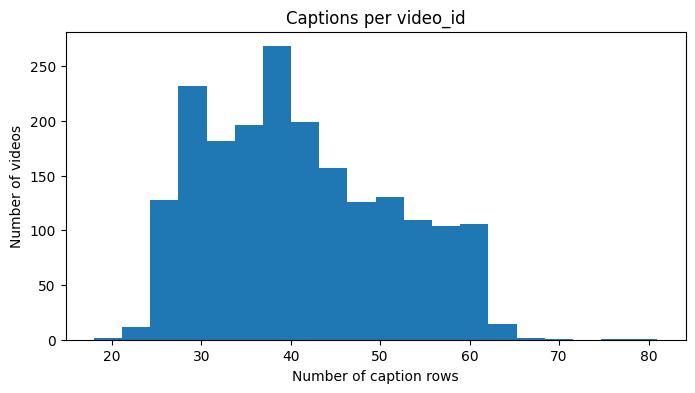

In [ ]:
captions_per_video.plot(kind='hist', bins=min(20, max(1, captions_per_video.nunique())),
                         title='Captions per video_id')
plt.xlabel('Number of caption rows')
plt.ylabel('Number of videos')
plt.show()


## 4. Caption length analysis

Word count and character count for both languages. Note: Nepali word count via
`.split()` is a rough proxy (Devanagari doesn't always space-delimit the way English
does), but it's good enough for a first pass.


In [ ]:
df['eng_word_count'] = df['eng_captions'].str.split().str.len()
df['eng_char_count'] = df['eng_captions'].str.len()

df['nep_word_count'] = df['nepali_captions'].str.split().str.len()
df['nep_char_count'] = df['nepali_captions'].str.len()

df[['eng_word_count', 'eng_char_count', 'nep_word_count', 'nep_char_count']].describe()


,eng_word_count,eng_char_count,nep_word_count,nep_char_count
count,80826.000000,80826.000000,80826.000000,80826.000000
mean,7.025759,33.779378,5.636627,33.311917
std,2.810564,13.908749,2.077287,13.248870
min,1.000000,2.000000,1.000000,2.000000
25%,5.000000,25.000000,4.000000,25.000000
50%,6.000000,31.000000,5.000000,30.000000
75%,8.000000,39.000000,6.000000,39.000000
max,45.000000,221.000000,40.000000,231.000000


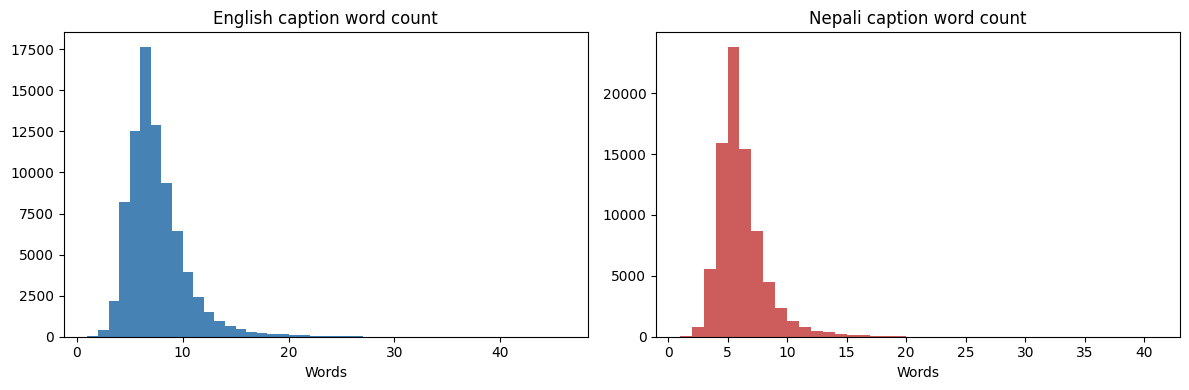

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['eng_word_count'], bins=range(1, df['eng_word_count'].max() + 2), color='steelblue')
axes[0].set_title('English caption word count')
axes[0].set_xlabel('Words')

axes[1].hist(df['nep_word_count'], bins=range(1, df['nep_word_count'].max() + 2), color='indianred')
axes[1].set_title('Nepali caption word count')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.show()


## 5. English vs. Nepali length relationship

Do longer English captions tend to have longer Nepali translations? Sanity-checks
alignment quality too — a huge mismatch in one row can flag a bad translation pair.


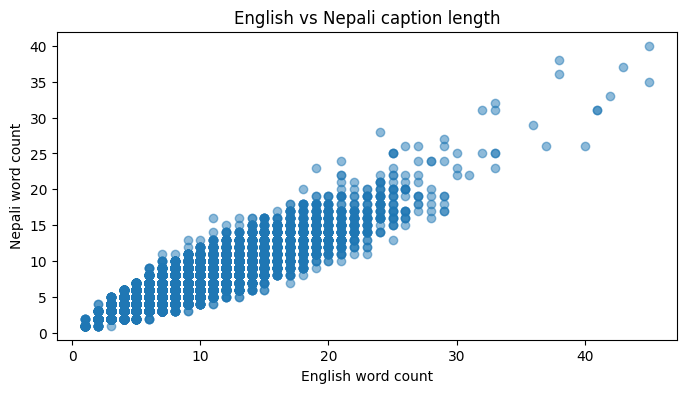

Correlation (word count): 0.865


In [ ]:
plt.scatter(df['eng_word_count'], df['nep_word_count'], alpha=0.5)
plt.xlabel('English word count')
plt.ylabel('Nepali word count')
plt.title('English vs Nepali caption length')
plt.show()

corr = df['eng_word_count'].corr(df['nep_word_count'])
print(f"Correlation (word count): {corr:.3f}")


## 6. Vocabulary — English side

Most common words, vocab size, and a rough sense of repetition across captions
(captioning datasets often reuse a small set of verbs/objects a lot).


In [ ]:
def tokenize_eng(text):
    return re.findall(r"[a-zA-Z']+", text.lower())

eng_tokens = df['eng_captions'].apply(tokenize_eng).explode()
eng_vocab_size = eng_tokens.nunique()
print(f"English vocab size: {eng_vocab_size}")
print(f"Total English tokens: {len(eng_tokens)}")

eng_tokens.value_counts().head(20)


English vocab size: 12503
Total English tokens: 567664


eng_captions
a          90400
is         44517
the        29203
man        23161
woman      10174
on          9428
in          9229
playing     7804
are         7138
of          6713
with        6307
and         6110
person      5052
to          4762
into        3728
an          3506
two         3497
dog         3409
cat         3343
girl        3306
Name: count, dtype: int64

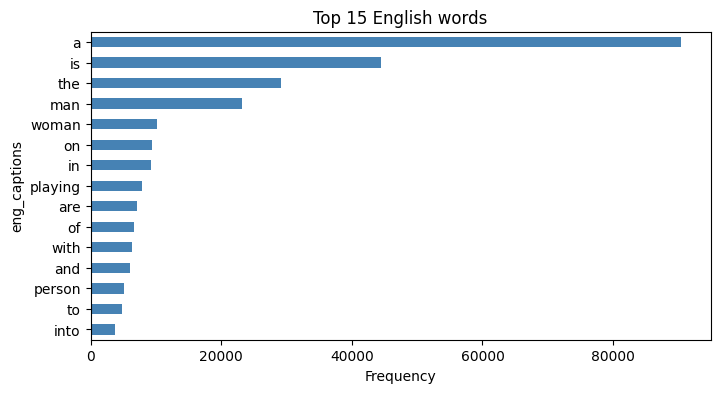

In [ ]:
top_words = eng_tokens.value_counts().head(15)
top_words.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 15 English words')
plt.xlabel('Frequency')
plt.show()


## 7. Vocabulary — Nepali side

Same idea, just splitting on whitespace since Devanagari word regex needs a different
approach than Latin script.


In [ ]:
nep_tokens = df['nepali_captions'].str.split().explode()
nep_vocab_size = nep_tokens.nunique()
print(f"Nepali vocab size: {nep_vocab_size}")
print(f"Total Nepali tokens: {len(nep_tokens)}")

nep_tokens.value_counts().head(20)


Nepali vocab size: 17581
Total Nepali tokens: 455586


nepali_captions
छ          28835
एक         23737
एउटा       17446
मानिस      12649
महिला       9896
एउटी        9409
छन्         9187
छिन्        7738
काट्दै      5300
आफ्नो       5070
र           5034
मानिसले     4435
गर्दै       3994
व्यक्ति     3917
बजाउँदै     3584
मान्छे      3364
गर्दैछ      3176
दुई         3058
कुकुर       2904
जना         2902
Name: count, dtype: int64

## 8. Duplicate & near-duplicate captions

Worth flagging exact duplicate `eng_captions` (same sentence reused across different
videos) since that affects train/test split decisions later.


In [ ]:
dup_eng = df['eng_captions'].value_counts()
dup_eng = dup_eng[dup_eng > 1]
print(f"English captions repeated more than once: {len(dup_eng)}")
dup_eng.head(10)


English captions repeated more than once: 6385


eng_captions
a man is playing a guitar      328
a man cooking his kichen       263
a man is playing guitar        162
a woman is riding a horse      127
a man is playing the guitar    115
a man is playing a flute        98
a woman is dancing              92
a man is dancing                88
a person is cooking             87
a baby is laughing              83
Name: count, dtype: int64

## 9. Random sample inspection

Eyeball a few pairs to sanity-check alignment quality.

In [ ]:
sample_n = min(5, len(df))
df[['video_id', 'eng_captions', 'nepali_captions']].sample(sample_n, random_state=42)


,video_id,eng_captions,nepali_captions
48222,b24_bb57PPk_631_637,a man is serving people at a table,एउटा मानिस टेबलमा बसेर मानिसहरूको सेवा गर्दैछ
6318,30GeJHYoerk_63_75,someone is twirling a pencil,कोही पेन्सिल घुमाउँदै छन्
43265,Y4BeJ-64294_20_30,a man is rapidly firing bullets at a drum filled with water,एक जना मानिसले पानीले भरिएको ड्रममा छिटोछिटो गोली हानेको छ
76123,wSwwS_0MKEc_68_78,a person is drinking beer from a glass,एक व्यक्ति गिलासबाट बियर पिइरहेको छ
4363,1TjqADyYyxI_36_45,the man fell down,मानिस तल झर्यो


## 10. Summary / takeaways

- Fill this in once run on the real dataset — things to look for:
  - Are caption lengths (English vs Nepali) roughly proportional, or are there
    outlier rows suggesting misaligned translations?
  - How skewed is the vocabulary (few words dominating vs. long tail)?
  - How many captions per video on average — is this a dense multi-caption-per-clip
    dataset or mostly 1:1?
  - Any exact duplicate captions that should be deduped before a train/val split?
